In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image and convert to HSV
image_path = '../data/raw/seam.jpg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Extract ONLY the Hue Channel (Index 0)
hue_channel = hsv[:, :, 0]

# 3. Calculate the Histogram for the Hue channel (0 to 180)
# cv2.calcHist(images, channels, mask, histSize, ranges)
hue_hist = cv2.calcHist([hue_channel], [0], None, [180], [0, 180])

# 4. Find the Peak (The most dominant color, which MUST be the grass)
# argmax() returns the index (the exact Hue number) with the highest pixel count
peak_hue = np.argmax(hue_hist)

# 5. DYNAMICALLY CALCULATE THE BOUNDS (Create a +/- 15 window around the peak)
hue_margin = 30
lower_hue = max(0, peak_hue - hue_margin)
upper_hue = min(179, peak_hue + hue_margin)

print(f"--- AUTOMATIC CALCULATION ---")
print(f"Detected Dominant Grass Hue: {peak_hue}")
print(f"Calculated Lower Bound: [ {lower_hue}, 20, 20 ]")
print(f"Calculated Upper Bound: [ {upper_hue}, 255, 255 ]\n")

# 6. Apply our dynamically calculated bounds to the standard inRange function
# (We keep Saturation and Value wide open to survive shadows and sun glare)
lower_green = np.array([lower_hue, 20, 20])
upper_green = np.array([upper_hue, 255, 255])

bg_mask = cv2.inRange(hsv, lower_green, upper_green)

# Invert to get the ball
ball_mask = cv2.bitwise_not(bg_mask)

# 7. Morphological Cleanup (Just like your original code)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
cleaned_mask = cv2.morphologyEx(ball_mask, cv2.MORPH_OPEN, kernel)
contours,_ =cv2.findContours(ball_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


--- AUTOMATIC CALCULATION ---
Detected Dominant Grass Hue: 24
Calculated Lower Bound: [ 0, 20, 20 ]
Calculated Upper Bound: [ 54, 255, 255 ]



In [2]:
if contours:
    # Get largest contour and prune it
    largest_contour = max(contours, key=cv2.contourArea)
    epsilon = 0.002 * cv2.arcLength(largest_contour, True)
    pruned_contour = cv2.approxPolyDP(largest_contour, epsilon, True)
    
    # Draw the final dynamic mask
    final_segmented_mask_1 = np.zeros_like(cleaned_mask)
    cv2.drawContours(final_segmented_mask_1, [pruned_contour], -1, 255, -1)
    
    # Extract the isolated ball for Phase 2/3
    isolated_ball_1 = cv2.bitwise_and(img_rgb, img_rgb, mask=final_segmented_mask_1)

    final_segmented_mask_2 = np.zeros_like(cleaned_mask)
    cv2.drawContours(final_segmented_mask_2, [largest_contour], -1, 255, -1)

    isolated_ball_2 = cv2.bitwise_and(img_rgb, img_rgb, mask=final_segmented_mask_2)


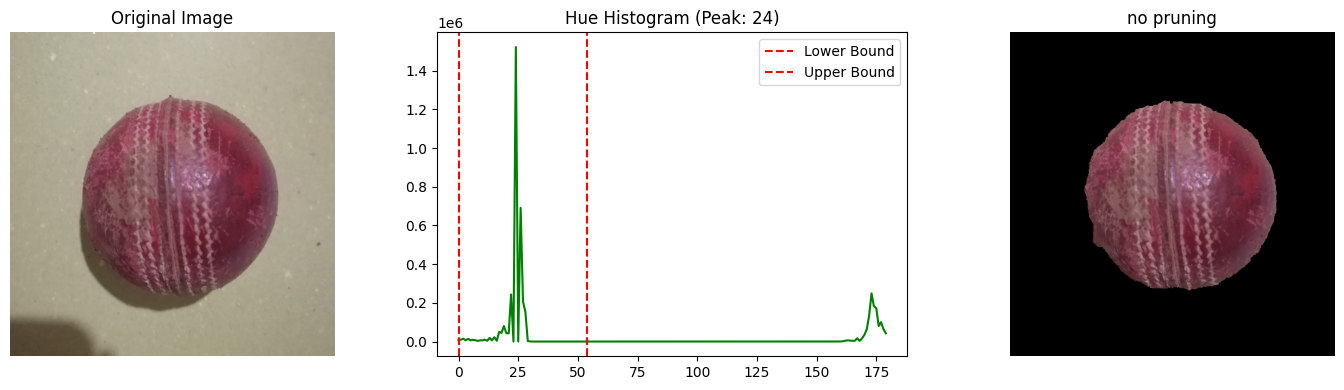

In [5]:
# --- VISUALIZATION ---
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Hue Histogram (Peak: {peak_hue})")
plt.plot(hue_hist, color='green')
plt.axvline(x=lower_hue, color='red', linestyle='--', label='Lower Bound')
plt.axvline(x=upper_hue, color='red', linestyle='--', label='Upper Bound')
plt.legend()

plt.subplot(1, 3, 3)
plt.title("no pruning")
plt.imshow(isolated_ball_2)
plt.axis('off')

plt.tight_layout()
plt.show()

--- 100% DYNAMIC HSV BOUNDS ---
Detected Peaks -> H:21 | S:15 | V:182
Calculated Lower Bound: [6, 10, 102]
Calculated Upper Bound: [36, 55, 255]



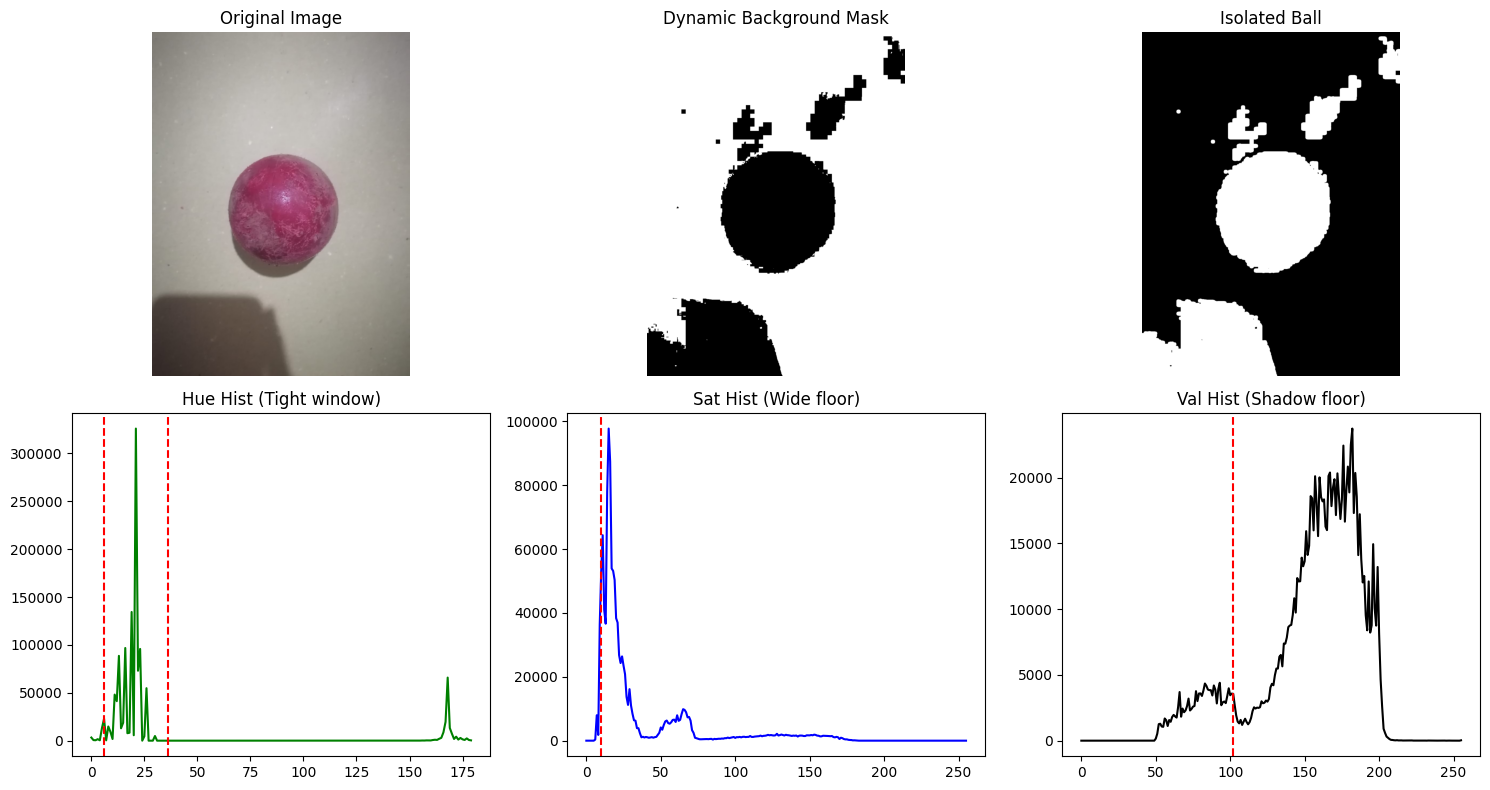

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image and convert to HSV
image_path = '../data/raw/controlled_bg.jpeg'
img = cv2.imread(image_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Split the channels
hue, sat, val = cv2.split(hsv)

# 3. Calculate Histograms for all three channels
# cv2.calcHist([image], [channel_index], mask, [bins], [range])
hist_h = cv2.calcHist([hue], [0], None, [180], [0, 180])
hist_s = cv2.calcHist([sat], [0], None, [256], [0, 256])
hist_v = cv2.calcHist([val], [0], None, [256], [0, 256])

# 4. Find the Peaks (The most dominant value in each channel)
peak_h = int(np.argmax(hist_h))
peak_s = int(np.argmax(hist_s))
peak_v = int(np.argmax(hist_v))

# 5. DYNAMICALLY CALCULATE ALL BOUNDS (The Asymmetric Logic)
# Hue gets a tight window (color is constant)
lower_h = max(0, peak_h - 15)
upper_h = min(179, peak_h + 15)

# Saturation gets a wide floor, ceiling open to 255
lower_s = max(10, peak_s - 40)
upper_s = min(255, peak_s +40)

# Value gets a massive floor to catch shadows, ceiling open to 255
lower_v = max(20, peak_v - 80)
upper_v = 255

print(f"--- 100% DYNAMIC HSV BOUNDS ---")
print(f"Detected Peaks -> H:{peak_h} | S:{peak_s} | V:{peak_v}")
print(f"Calculated Lower Bound: [{lower_h}, {lower_s}, {lower_v}]")
print(f"Calculated Upper Bound: [{upper_h}, {upper_s}, {upper_v}]\n")

# 6. Apply the fully dynamic bounds
lower_green = np.array([lower_h, lower_s, 20])
upper_green = np.array([upper_h, upper_s, 255])

bg_mask = cv2.inRange(hsv, lower_green, upper_green)

# 7. Invert and Clean (Standard Phase 1 Logic)
ball_mask = cv2.bitwise_not(bg_mask)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
cleaned_mask = cv2.morphologyEx(ball_mask, cv2.MORPH_OPEN, kernel)

# --- VISUALIZATION ---
plt.figure(figsize=(15, 8))

# Top Row: The Images
plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Dynamic Background Mask")
plt.imshow(bg_mask, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Isolated Ball")
plt.imshow(cleaned_mask, cmap='gray')
plt.axis('off')

# Bottom Row: The Histograms
plt.subplot(2, 3, 4)
plt.title(f"Hue Hist (Tight window)")
plt.plot(hist_h, color='green')
plt.axvline(x=lower_h, color='red', linestyle='--')
plt.axvline(x=upper_h, color='red', linestyle='--')

plt.subplot(2, 3, 5)
plt.title(f"Sat Hist (Wide floor)")
plt.plot(hist_s, color='blue')
plt.axvline(x=lower_s, color='red', linestyle='--')

plt.subplot(2, 3, 6)
plt.title(f"Val Hist (Shadow floor)")
plt.plot(hist_v, color='black')
plt.axvline(x=lower_v, color='red', linestyle='--')

plt.tight_layout()
plt.show()